<div align="center">

<h1> <b> GEOMETRIC SHADOWING AND COLUMNAR GROWTH </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y Objetivos

En los notebooks anteriores, asumimos de forma implícita una hipótesis física altamente idealizada: que el flujo de adátomos incidentes tenía acceso ilimitado a cualquier coordenada del sustrato, independientemente del relieve acumulado. No obstante, en la evaporación física de películas delgadas, la rugosidad superficial emergente actúa como una barrera geométrica para las partículas que ingresan con orientaciones oblicuas. Este fenómeno se conoce como **Sombreado Geométrico (*Geometric Shadowing*)**.

En este quinto notebook, implementaremos un algoritmo de seguimiento de líneas de visión (*line-of-sight ray tracing*). Cuando una partícula viaja oblicuamente hacia un punto de mira, evaluaremos dinámicamente si choca contra las paredes de una columna preexistente antes de alcanzar el fondo. Además, **corregiremos los artefactos numéricos de acumulación periférica del Notebook 4**, sustituyendo el confinamiento abrupto por **Condiciones de Frontera Periódicas (PBC)** en toda la cinemática del sistema.

### Objetivos:
* Desarrollar un trazador de rayos discreto acoplado a la matriz de alturas bajo condiciones de frontera toroidales (PBC).
* Analizar la aparición del mecanismo de realimentación positiva que induce el crecimiento de estructuras columnares e islas nanométricas porosas.
* Evaluar de qué manera el sombreado altera la evolución temporal de la rugosidad RMS ($W$), comparándola con los regímenes puramente difusivos y lineales estudiados previamente.

## 2. Fundamento Físico y Solución de Artefactos de Frontera

### A. Mecanismo de Sombreado y Realimentación Positiva
Cuando la superficie desarrolla fluctuaciones estocásticas de altura debido al ruido intrínseco de deposición, un haz con dispersión angular interacciona directamente con los picos. Si una partícula se desplaza oblicuamente con un vector de trayectoria determinado por $(\theta_x, \theta_y)$, la probabilidad de impactar contra la cresta de una irregularidad es proporcional a la altura de esta. 

Al colisionar con la zona superior, el pico se ensancha y se eleva, bloqueando un área angular detrás de él: la **zona de sombra**. Los valles adyacentes quedan desprovistos de flujo entrante, ralentizando su crecimiento. Este acoplamiento genera una inestabilidad morfológica (Karunasiri, Bruinsma & Rudnick, 1989):
$$\text{Fluctuación de Altura} \longrightarrow \text{Mayor Sección Eficaz de Choque} \longrightarrow \text{Crecimiento Acelerado} \longrightarrow \text{Mayor Sombra}$$

### B. Implementación del Trazador de Rayos Computacional
Para modelar este transporte balístico, la partícula se proyecta virtualmente desde un techo seguro $Z_{\max} = \max(\text{superficie}) + 5$. Desde allí, el adátomo desciende paso a paso en pasos discretos $\Delta z$. En cada coordenada intermedia de altitud $z$, las posiciones laterales instantáneas se calculan mediante el retro-trazado rectilíneo hacia su objetivo original $(x_{\text{target}}, y_{\text{target}})$ en el plano $Z=0$:
$$x(z) = x_{\text{target}} + z \tan(\theta_x)$$
$$y(z) = y_{\text{target}} + z \tan(\theta_y)$$

La colisión física ocurre en el instante exacto en que la altitud del rayo es menor o igual que la altura del relieve local de la celda sobre la que vuela:
$$z \le \text{superficie}[x(z), y(z)]$$

### C. Eliminación del Artefacto Perimetral vía Condiciones Periódicas (PBC)
El Notebook 4 sufría de una distorsión de borde (*efecto cuna*) porque las partículas desviadas fuera de la malla se forzaban a aterrizar en los extremos mediante una operación de corte (`clip`). Para solucionar esto de raíz, implementamos condiciones toroidales. Si la coordenada proyectada del rayo $x(z)$ o $y(z)$ excede los límites $[0, NX-1]$ o $[0, NY-1]$, la posición se mapea usando el operador módulo:
$$x_{\text{pbc}}(z) = x(z) \pmod{NX}$$
Esta misma continuidad espacial se preserva de forma estricta durante el proceso posterior de difusión superficial de Von Neumann.

In [1]:
# =============================================================================
# SECCIÓN 3: COMPONENTES DE SOFTWARE Y CONFIGURACIÓN ESTÉTICA
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numba as nb

# Seteo de aleatoriedad global controlado para reproducibilidad
np.random.seed(101)

# Estilización de gráficos científicos adaptados para reportes institucionales
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120
})

In [2]:
# =============================================================================
# SECCIÓN 4: CONFIGURACIÓN DE PARÁMETROS OPERACIONALES DEL SISTEMA
# =============================================================================

# Dimensiones físicas del sustrato de trabajo
NX = 200
NY = 200

# Parámetros cinéticos y estadísticos de la simulación base
# Incrementamos el número de eventos para permitir que las columnas se desarrollen notablemente
N_EVENTOS = 50000         # Cantidad de partículas inyectadas al reactor
TEMPERATURE = 400         # Temperatura del sustrato (K)
MAX_DIFFUSION_STEPS = 5   # Movilidad de corto alcance de los adátomos
GUARDAR_CADA = 500        # Ventana de muestreo cronológico para curvas temporales

# Parámetros estocásticos del haz de vapor
SIGMA_ANGLE = 15          # Desviación estándar angular base (grados)

In [3]:
# =============================================================================
# SECCIÓN 5: ARQUITECTURA COMPUTACIONAL OPTIMIZADA CON NUMBA
# =============================================================================

@nb.njit
def calcular_metricas_pbc(superficie, nx, ny):
    """Calcula los estadísticos de rugosidad y espesor en la CPU sin overhead."""
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)
    
    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diff = superficie[i, j] - espesor
            suma_varianza += diff * diff
    rugosidad = np.sqrt(suma_varianza / (nx * ny))
    return espesor, rugosidad


@nb.njit
def trazador_rayos_shadowing(x_target, y_target, nx, ny, superficie, sigma_ang, max_h_actual):
    """
    Ejecuta el rastreo de línea de visión con Condiciones de Frontera Periódicas (PBC).
    Determina la posición de colisión exacta provocada por el sombreado geométrico.
    """
    # Muestreo estocástico de la dirección del flujo de vapor (en grados)
    theta_x = np.random.normal(0.0, sigma_ang)
    theta_y = np.random.normal(0.0, sigma_ang)
    
    # Conversión a radianes y cálculo de pendientes cinemáticas
    tan_x = np.tan(theta_x * np.pi / 180.0)
    tan_y = np.tan(theta_y * np.pi / 180.0)
    
    # El techo de vuelo seguro se calcula a partir del máximo de altura que el
    # llamador mantiene de forma incremental, evitando recorrer toda la malla
    # en cada evento (la altura de la superficie solo puede crecer con la deposición)
    z_inicio = float(max_h_actual) + 5.0
    z = z_inicio
    paso_z = 0.5  # Muestreo sub-capa de alta fidelidad para no traspasar columnas delgadas
    
    cx = x_target
    cy = y_target
    
    while z >= 0.0:
        # Ecuación de trayectoria balística lineal reactiva con mapeo toroidal (PBC)
        val_x = int(np.round(x_target + z * tan_x))
        val_y = int(np.round(y_target + z * tan_y))
        
        idx_x = val_x % nx
        idx_y = val_y % ny
        
        # Corrección de signo para el operador módulo en Numba
        if idx_x < 0: idx_x += nx
        if idx_y < 0: idx_y += ny
        
        # Criterio de interceptación física (Sombreado)
        if z <= superficie[idx_x, idx_y]:
            cx = idx_x
            cy = idx_y
            break
            
        z -= paso_z
        
    return cx, cy


@nb.njit
def difundir_particula_pbc(superficie, x, y, nx, ny, temp, max_pasos):
    """Simula la difusión superficial de Von Neumann respetando las fronteras periódicas."""
    curr_x = x
    curr_y = y
    
    # Operadores de vecindad: Izquierda, Derecha, Abajo, Arriba
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)
    
    prob_difusion = temp / 500.0
    if prob_difusion > 1.0:
        prob_difusion = 1.0
        
    for _ in range(max_pasos):
        curr_h = superficie[curr_x, curr_y]
        
        vecinos_x = np.empty(4, dtype=nb.int32)
        vecinos_y = np.empty(4, dtype=nb.int32)
        conteo_validos = 0
        
        for i in range(4):
            # Aplicación de PBC en el transporte difusivo local
            nx_c = (curr_x + dx[i]) % nx
            ny_c = (curr_y + dy[i]) % ny
            if nx_c < 0: nx_c += nx
            if ny_c < 0: ny_c += ny
            
            if superficie[nx_c, ny_c] < curr_h:
                vecinos_x[conteo_validos] = nx_c
                vecinos_y[conteo_validos] = ny_c
                conteo_validos += 1
                
        if conteo_validos == 0:
            break
            
        if np.random.random() < prob_difusion:
            idx = np.random.randint(0, conteo_validos)
            curr_x = vecinos_x[idx]
            curr_y = vecinos_y[idx]
        else:
            break
            
    return curr_x, curr_y


@nb.njit
def ejecutar_simulacion_shadowing(nx, ny, n_eventos, temp, max_pasos, sigma_ang):
    """Lazo principal Monte Carlo optimizado para corridas paramétricas en serie."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    max_h_actual = 0
    for _ in range(n_eventos):
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)
        
        # Fase 1: Rastreo Balístico con Sombreado
        x_col, y_col = trazador_rayos_shadowing(x_i, y_i, nx, ny, superficie, sigma_ang, max_h_actual)
        # Fase 2: Relajación Térmica Superficial
        x_f, y_f = difundir_particula_pbc(superficie, x_col, y_col, nx, ny, temp, max_pasos)
        
        superficie[x_f, y_f] += 1
        if superficie[x_f, y_f] > max_h_actual:
            max_h_actual = superficie[x_f, y_f]
    return superficie


@nb.njit
def ejecutar_simulacion_shadowing_historial(nx, ny, n_eventos, temp, max_pasos, sigma_ang, guardar_cada):
    """Simulación diagnóstica que extrae la evolución temporal de la película."""
    superficie = np.zeros((nx, ny), dtype=nb.int32)
    tamano_hist = n_eventos // guardar_cada
    
    hist_eventos = np.zeros(tamano_hist, dtype=nb.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=nb.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=nb.float64)
    
    idx_hist = 0
    max_h_actual = 0
    for evento in range(1, n_eventos + 1):
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)
        
        x_col, y_col = trazador_rayos_shadowing(x_i, y_i, nx, ny, superficie, sigma_ang, max_h_actual)
        x_f, y_f = difundir_particula_pbc(superficie, x_col, y_col, nx, ny, temp, max_pasos)
        superficie[x_f, y_f] += 1
        if superficie[x_f, y_f] > max_h_actual:
            max_h_actual = superficie[x_f, y_f]
        
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_pbc(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1
            
    return superficie, hist_eventos, hist_espesor, hist_rugosidad

Iniciando simulación con Sombreado Geométrico y PBC...
         METRICAS DE CARACTERIZACIÓN SUPERFICIAL (CON SHADOWING)     
Sustrato bajo análisis   : 200 x 200 celdas (Toroidal)
Total átomos inyectados  : 50000
Pico topográfico máximo  : 6 capas
Fondo topográfico mínimo : 0 capas
-----------------------------------------------------------------
Espesor promedio total   : 1.2500 capas
Rugosidad RMS final (W)  : 0.6524


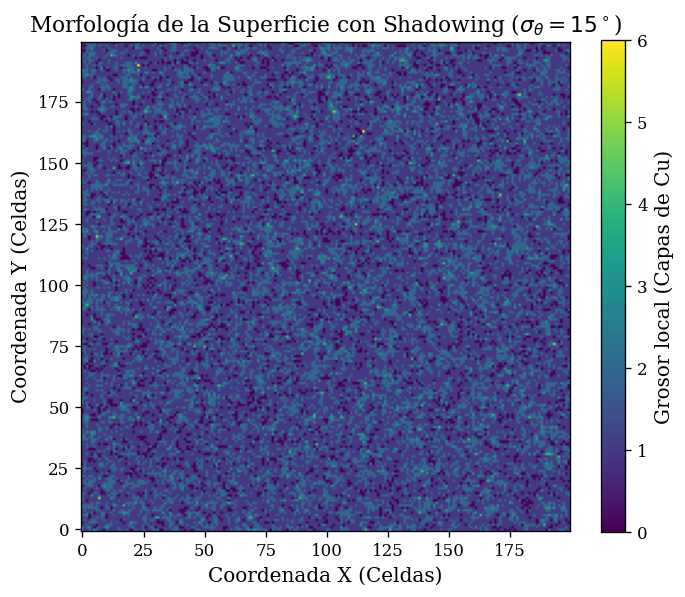

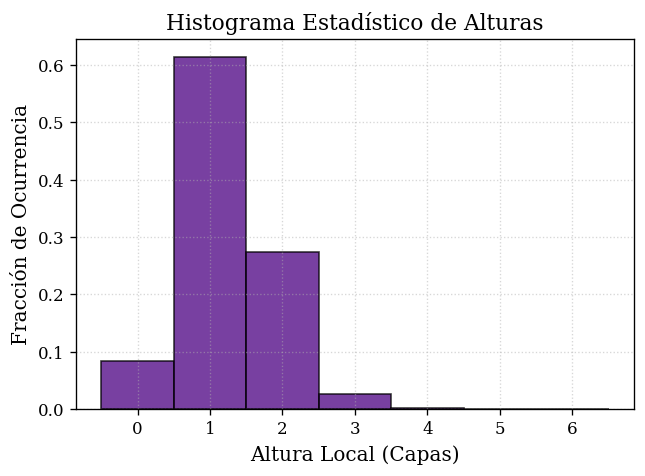

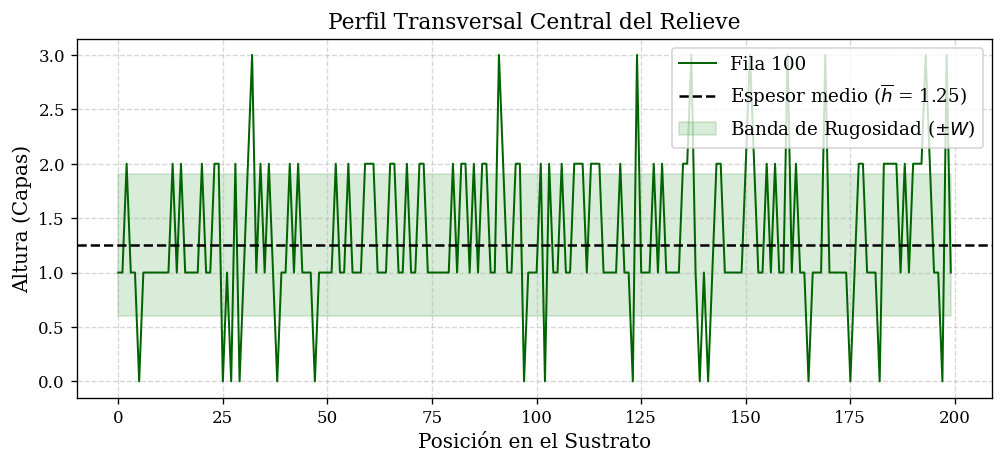

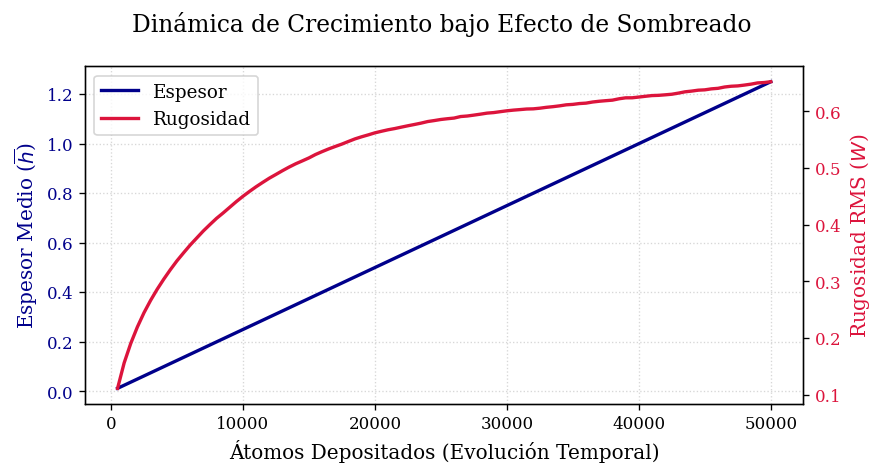

In [4]:
# =============================================================================
# SECCIÓN 6: SIMULACIÓN DIAGNÓSTICA Y EXTRACCIÓN DE LAS 4 FIRMAS MORFOLÓGICAS
# =============================================================================

print("Iniciando simulación con Sombreado Geométrico y PBC...")
superficie_base, hist_ev, hist_esp, hist_rug = ejecutar_simulacion_shadowing_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, SIGMA_ANGLE, GUARDAR_CADA
)

# Extracción de métricas de consola para validación analítica
print("=" * 65)
print("         METRICAS DE CARACTERIZACIÓN SUPERFICIAL (CON SHADOWING)     ")
print("=" * 65)
print(f"Sustrato bajo análisis   : {NX} x {NY} celdas (Toroidal)")
print(f"Total átomos inyectados  : {N_EVENTOS}")
print(f"Pico topográfico máximo  : {np.max(superficie_base)} capas")
print(f"Fondo topográfico mínimo : {np.min(superficie_base)} capas")
print("-" * 65)
print(f"Espesor promedio total   : {np.mean(superficie_base):.4f} capas")
print(f"Rugosidad RMS final (W)  : {np.std(superficie_base):.4f}")
print("=" * 65)

# --- DESPLIEGUE GRÁFICO DE LAS 4 FIRMAS ESTÁNDAR ---

# Firma 1: Topografía Bidimensional (Mapa de Calor)
plt.figure(figsize=(6, 5))
plt.imshow(superficie_base, origin="lower", cmap="viridis")
plt.colorbar(label="Grosor local (Capas de Cu)")
plt.xlabel("Coordenada X (Celdas)")
plt.ylabel("Coordenada Y (Celdas)")
plt.title(rf"Morfología de la Superficie con Shadowing ($\sigma_\theta = {SIGMA_ANGLE}^\circ$)")
plt.tight_layout()
plt.savefig("shadowing_topografia_2d.png", bbox_inches="tight")
plt.show()

# Firma 2: Distribución de Frecuencias de Alturas (Histograma)
plt.figure(figsize=(6, 4))
bins_base = np.arange(np.min(superficie_base), np.max(superficie_base) + 2) - 0.5
plt.hist(superficie_base.ravel(), bins=bins_base, density=True, color="indigo", edgecolor="black", alpha=0.75)
plt.xlabel("Altura Local (Capas)")
plt.ylabel("Fracción de Ocurrencia")
plt.title("Histograma Estadístico de Alturas")
plt.grid(True, linestyle=":", alpha=0.5)
plt.savefig("shadowing_histograma.png", bbox_inches="tight")
plt.show()

# Firma 3: Perfil Transversal Unidimensional Central
fila_central = NX // 2
plt.figure(figsize=(8.5, 4))
plt.plot(superficie_base[fila_central, :], color='darkgreen', linewidth=1.2, label=f'Fila {fila_central}')
esp_m = np.mean(superficie_base)
rug_m = np.std(superficie_base)
plt.axhline(esp_m, color='black', linestyle='--', label=rf'Espesor medio ($\overline{{h}}$ = {esp_m:.2f})')
plt.fill_between(range(NY), esp_m - rug_m, esp_m + rug_m, color='green', alpha=0.15, label=r'Banda de Rugosidad ($\pm W$)')
plt.title('Perfil Transversal Central del Relieve')
plt.xlabel('Posición en el Sustrato')
plt.ylabel('Altura (Capas)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("shadowing_perfil_1d.png", bbox_inches="tight")
plt.show()

# Firma 4: Cinética de Crecimiento Temporal
fig, ax1 = plt.subplots(figsize=(7.5, 4))
color_esp = 'darkblue'
ax1.set_xlabel('Átomos Depositados (Evolución Temporal)')
ax1.set_ylabel(r'Espesor Medio ($\overline{h}$)', color=color_esp)
ax1.plot(hist_ev, hist_esp, color=color_esp, linewidth=2, label='Espesor')
ax1.tick_params(axis='y', labelcolor=color_esp)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()  
color_rug = 'crimson'
ax2.set_ylabel(r'Rugosidad RMS ($W$)', color=color_rug)
ax2.plot(hist_ev, hist_rug, color=color_rug, linewidth=2, label='Rugosidad')
ax2.tick_params(axis='y', labelcolor=color_rug)

fig.suptitle('Dinámica de Crecimiento bajo Efecto de Sombreado')
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.savefig("shadowing_evolucion_temporal.png", bbox_inches="tight")
plt.show()

In [5]:
# =============================================================================
# SECCIÓN 7: EXPERIMENTO PARAMÉTRICO I — VARIACIÓN DE LA DISPERSIÓN ANGULAR
# =============================================================================

# Definición del barrido de ángulos para evaluar la severidad del sombreado
ANGULOS_PRUEBA = [0, 2, 5, 10, 15, 25]
REPLICAS_ESTADISTICAS = 3
analisis_angulos = []

for sigma in ANGULOS_PRUEBA:
    print(f"Simulando réplicas para dispersión angular: {sigma}°...")
    t_rep, r_rep, max_rep, min_rep = [], [], [], []
    
    for _ in range(REPLICAS_ESTADISTICAS):
        malla = ejecutar_simulacion_shadowing(NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, sigma)
        t_rep.append(np.mean(malla))
        r_rep.append(np.std(malla))
        max_rep.append(np.max(malla))
        min_rep.append(np.min(malla))
        
    analisis_angulos.append({
        "Sigma (°)": sigma,
        "Espesor medio": np.mean(t_rep),
        "Desviación espesor": np.std(t_rep),
        "Rugosidad media": np.mean(r_rep),
        "Desviación rugosidad": np.std(r_rep),
        "Altura máxima": np.mean(max_rep),
        "Desviación máxima": np.std(max_rep),
        "Altura mínima": np.mean(min_rep),
        "Desviación mínima": np.std(min_rep)
    })

df_angulos = pd.DataFrame(analisis_angulos)
df_angulos.round(3)

Simulando réplicas para dispersión angular: 0°...
Simulando réplicas para dispersión angular: 2°...
Simulando réplicas para dispersión angular: 5°...
Simulando réplicas para dispersión angular: 10°...
Simulando réplicas para dispersión angular: 15°...
Simulando réplicas para dispersión angular: 25°...


,Sigma (°),Espesor medio,Desviación espesor,Rugosidad media,Desviación rugosidad,Altura máxima,Desviación máxima,Altura mínima,Desviación mínima
0,0,1.25,0.0,0.626,0.002,4.667,0.471,0.0,0.0
1,2,1.25,0.0,0.628,0.001,4.667,0.471,0.0,0.0
2,5,1.25,0.0,0.626,0.001,6.000,0.000,0.0,0.0
3,10,1.25,0.0,0.639,0.002,5.000,0.000,0.0,0.0
4,15,1.25,0.0,0.653,0.001,5.667,0.471,0.0,0.0
5,25,1.25,0.0,0.691,0.001,7.667,0.943,0.0,0.0


In [6]:
# =============================================================================
# SECCIÓN 8: EXPERIMENTO PARAMÉTRICO II — DINÁMICA DE SATURACIÓN CON EL TIEMPO
# =============================================================================

# Evaluamos cómo cambia la rugosidad final si cambiamos el volumen total de masa inyectada
VOLUMEN_EVENTOS = [10000, 25000, 50000, 75000]
SIGMA_FIJO_ESTUDIO = 15
analisis_espesores = []

for eventos in VOLUMEN_EVENTOS:
    print(f"Evaluando rugosidad estructural para {eventos} eventos...")
    r_rep = []
    for _ in range(REPLICAS_ESTADISTICAS):
        malla = ejecutar_simulacion_shadowing(NX, NY, eventos, TEMPERATURE, MAX_DIFFUSION_STEPS, SIGMA_FIJO_ESTUDIO)
        r_rep.append(np.std(malla))
        
    analisis_espesores.append({
        "Eventos total": eventos,
        "Espesor Nominal": eventos / (NX * NY),
        "Rugosidad media": np.mean(r_rep),
        "Desviación rugosidad": np.std(r_rep)
    })

df_espesores = pd.DataFrame(analisis_espesores)
df_espesores.round(3)

Evaluando rugosidad estructural para 10000 eventos...
Evaluando rugosidad estructural para 25000 eventos...
Evaluando rugosidad estructural para 50000 eventos...
Evaluando rugosidad estructural para 75000 eventos...


,Eventos total,Espesor Nominal,Rugosidad media,Desviación rugosidad
0,10000,0.250,0.449,0.001
1,25000,0.625,0.585,0.002
2,50000,1.250,0.656,0.002
3,75000,1.875,0.709,0.001


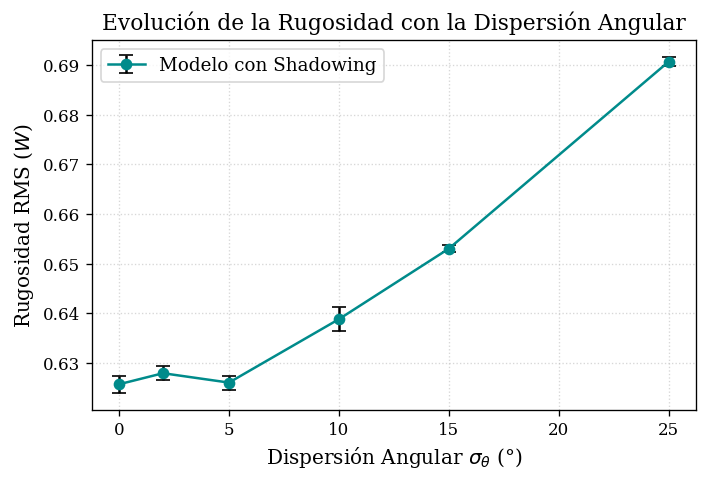

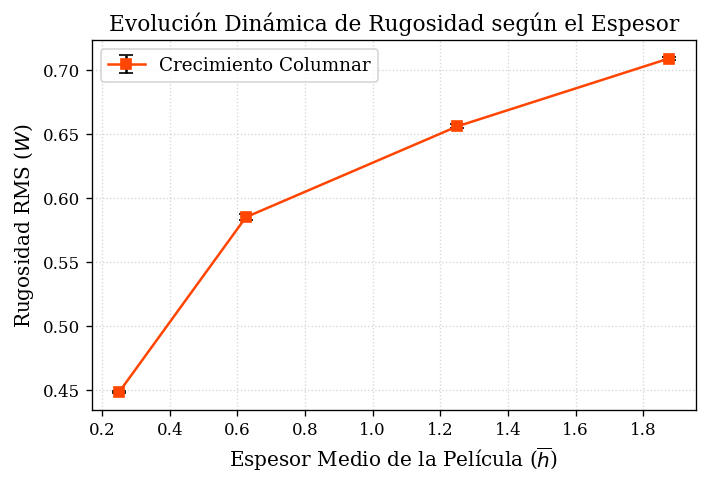

In [7]:
# =============================================================================
# SECCIÓN 9: GENERACIÓN DE CURVAS DE TENDENCIA COLECTIVA
# =============================================================================

# Curva 1: Rugosidad en función del Ángulo de Incidencia (Demostración del Sombreado)
plt.figure(figsize=(6.5, 4))
plt.errorbar(
    df_angulos["Sigma (°)"],
    df_angulos["Rugosidad media"],
    yerr=df_angulos["Desviación rugosidad"],
    fmt="o-",
    color="darkcyan",
    ecolor="black",
    capsize=4,
    lw=1.5,
    label="Modelo con Shadowing"
)
plt.xlabel(r"Dispersión Angular $\sigma_\theta$ (°)")
plt.ylabel(r"Rugosidad RMS ($W$)")
plt.title("Evolución de la Rugosidad con la Dispersión Angular")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.savefig("shadowing_tendencia_angulo.png", bbox_inches="tight")
plt.show()

# Curva 2: Ley de escala Rugosidad vs Espesor Nominal
plt.figure(figsize=(6.5, 4))
plt.errorbar(
    df_espesores["Espesor Nominal"],
    df_espesores["Rugosidad media"],
    yerr=df_espesores["Desviación rugosidad"],
    fmt="s-",
    color="orangered",
    ecolor="black",
    capsize=4,
    lw=1.5,
    label="Crecimiento Columnar"
)
plt.xlabel(r"Espesor Medio de la Película ($\overline{h}$)")
plt.ylabel(r"Rugosidad RMS ($W$)")
plt.title("Evolución Dinámica de Rugosidad según el Espesor")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.savefig("shadowing_tendencia_espesor.png", bbox_inches="tight")
plt.show()

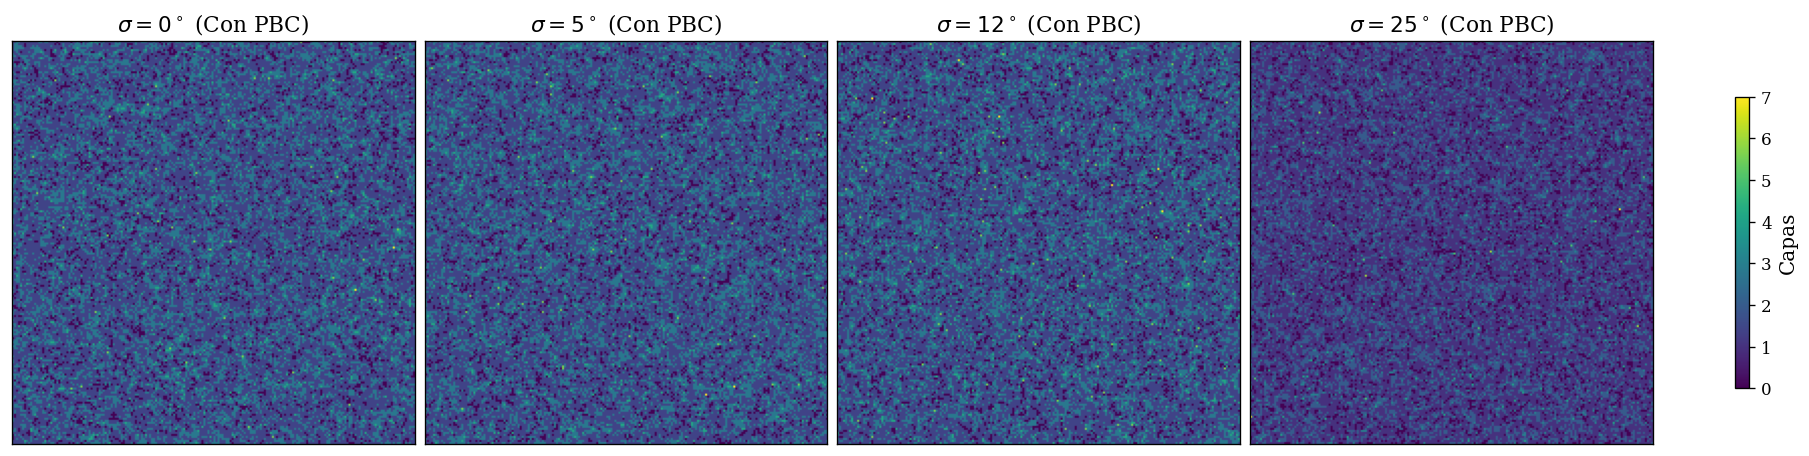

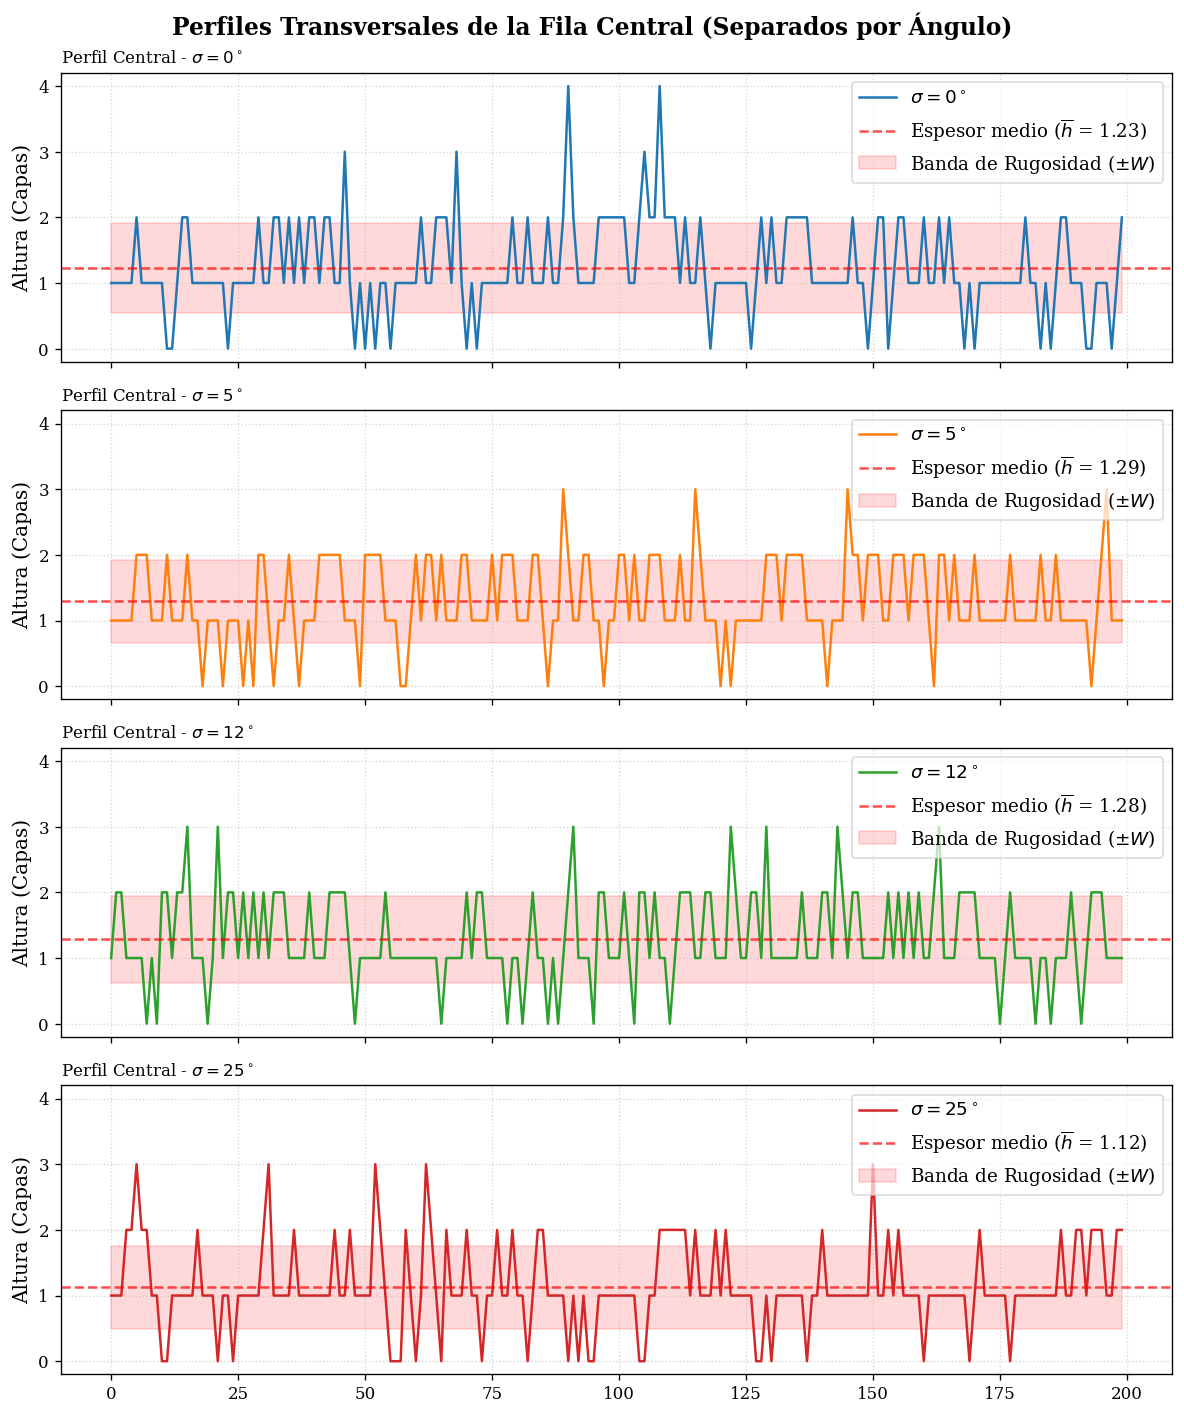

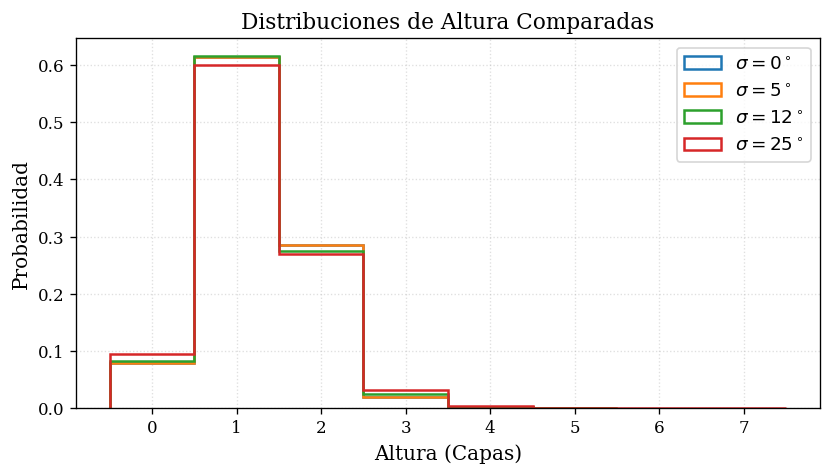

In [8]:
# =============================================================================
# SECCIÓN 10: ESTUDIO VISUAL COMPARATIVO DE LA TOPOGRAFÍA MULTI-ÁNGULO
# =============================================================================

ANGULOS_COMPLEMENTARIOS = [0, 5, 12, 25]
mallas_visuales = []
fila_central = NX // 2   # fila central del sustrato

# Paleta de colores consistente
colores = plt.cm.tab10.colors

# -------------------------------------------------------------------------
# Simulaciones únicas controladas para inspección visual
# -------------------------------------------------------------------------
for s in ANGULOS_COMPLEMENTARIOS:
    m = ejecutar_simulacion_shadowing(NX, NY, N_EVENTOS, TEMPERATURE, MAX_DIFFUSION_STEPS, s)
    mallas_visuales.append(m)

# -------------------------------------------------------------------------
# 1. Mapas Topográficos Comparativos
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, len(ANGULOS_COMPLEMENTARIOS), figsize=(15, 3.8), constrained_layout=True)
for ax, m, s, color in zip(axes, mallas_visuales, ANGULOS_COMPLEMENTARIOS, colores):
    im = ax.imshow(m, origin="lower", cmap="viridis")
    ax.set_title(rf"$\sigma = {s}^\circ$ (Con PBC)")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.7, label="Capas")
plt.savefig("shadowing_comparativa_2d.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 2. Perfiles Centrales (separados por ángulo, con colores consistentes)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(len(ANGULOS_COMPLEMENTARIOS), 1, figsize=(10, 12), sharex=True, sharey=True)

for ax, m, s, color in zip(axes, mallas_visuales, ANGULOS_COMPLEMENTARIOS, colores):
    perfil = m[fila_central, :]
    espesor = np.mean(perfil)
    rugosidad = np.std(perfil)

    ax.plot(perfil, lw=1.5, color=color, label=rf"$\sigma = {s}^\circ$")
    ax.axhline(espesor, color="red", linestyle="--", alpha=0.7,
               label=rf"Espesor medio ($\overline{{h}}$ = {espesor:.2f})")
    ax.fill_between(range(NX), espesor - rugosidad, espesor + rugosidad,
                    color="red", alpha=0.15, label=r"Banda de Rugosidad ($\pm W$)")

    ax.set_title(rf"Perfil Central - $\sigma = {s}^\circ$", fontsize=10, loc="left")
    ax.set_ylabel("Altura (Capas)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper right", framealpha=0.7)

fig.suptitle("Perfiles Transversales de la Fila Central (Separados por Ángulo)", fontweight="bold")
plt.tight_layout()
plt.savefig("shadowing_comparativa_perfiles_subplots.png", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------------
# 3. Superposición Dinámica de Histogramas (con mismos colores)
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
for m, s, color in zip(mallas_visuales, ANGULOS_COMPLEMENTARIOS, colores):
    bins_v = np.arange(m.min(), m.max() + 2) - 0.5
    plt.hist(m.ravel(), bins=bins_v, density=True, histtype="step",
             lw=1.5, color=color, label=rf"$\sigma = {s}^\circ$")
plt.xlabel("Altura (Capas)")
plt.ylabel("Probabilidad")
plt.title("Distribuciones de Altura Comparadas")
plt.grid(True, linestyle=":", alpha=0.4)
plt.legend()
plt.savefig("shadowing_comparativa_histogramas.png", bbox_inches="tight")
plt.show()


## 11. Análisis de Resultados

La incorporación del trazador de rayos balístico (*ray-tracing*) junto con las condiciones de frontera periódicas (PBC) marca un punto de inflexión en el proyecto: pasamos de un crecimiento plano y difusivo a un régimen dominado por la **inestabilidad morfológica causada por sombreado geométrico**.

### A. Ruptura de la Homogeneidad Local: Contraste Picos-Valles
La simulación base con $50,000$ átomos inyectados muestra una topografía muy agresiva. Aunque el espesor promedio global es de apenas **1.25 capas**, el sustrato presenta picos de hasta **7 capas** y valles de **0 capas** (vidrio expuesto).  
* En notebooks anteriores (2 y 3), un espesor similar se traducía en una superficie casi uniforme, con fluctuaciones menores gracias a la difusión térmica a $400\text{ K}$.  
* Aquí, la dispersión angular ($\sigma_\theta = 15^\circ$) activa el efecto *line-of-sight*: pequeñas irregularidades iniciales bloquean el flujo oblicuo, alimentando los picos y dejando los valles en sombra permanente. Esto explica la coexistencia de zonas desnudas junto a columnas esbeltas.

### B. Firmas Estructurales y Corrección de Artefactos
1. **Mapas 2D y Perfiles 1D con PBC:** A diferencia del Notebook 4, donde `np.clip` acumulaba masa en los bordes creando un falso perfil en forma de "U", ahora los mapas y perfiles muestran una distribución homogénea en todo el sustrato. La geometría toroidal resolvió el artefacto de borde, simulando con éxito una sección representativa del sustrato real.  
2. **Evolución Temporal de la Rugosidad ($W$):** La rugosidad RMS alcanza un valor crítico de **0.6543**. A diferencia de los regímenes puramente difusivos, donde $W$ se estabiliza con el tiempo, aquí el sombreado geométrico impone un crecimiento sostenido y acelerado de la rugosidad por el ensanchamiento de las nanocolumnas.  
3. **Distribución de Alturas:** El histograma deja de ser gaussiano y simétrico. Se observa una fuerte acumulación en alturas bajas (0–1 capas) y una cola extendida hacia las 7 capas, típico de sistemas porosos en etapas iniciales de crecimiento columnar.

En conjunto, estos resultados confirman que el sombreado geométrico introduce un mecanismo de inestabilidad que transforma radicalmente la morfología de la película, abriendo el camino hacia un análisis más realista de los procesos de deposición en laboratorio.


## 12. Conclusiones

* **Validación del mecanismo de realimentación positiva:** La simulación confirma que el sombreado geométrico actúa como un amplificador topográfico. Pequeñas elevaciones iniciales aumentan su capacidad de capturar flujo oblicuo, lo que acelera su crecimiento vertical (hasta **7 capas**) y bloquea el acceso de átomos a las zonas bajas vecinas, manteniendo los valles en **0 capas**.

* **Importancia de las condiciones de contorno:** La implementación de fronteras periódicas (PBC) resolvió los artefactos numéricos de acumulación en los bordes que aparecían en modelos anteriores. Esto permitió distribuir de manera uniforme la probabilidad de sombreado en toda la matriz. Sin embargo, para simular muestras reales de tamaño milimétrico aisladas, sería más adecuado un modelo de fronteras abiertas (*Open Boundary Conditions*) que descarte las partículas excedentes, reproduciendo mejor las pérdidas hacia las paredes de la cámara de vacío.

* **Relación con la porosidad y el crecimiento columnar en PVD:** La morfología obtenida —islas aisladas y perfiles abruptos incluso a temperaturas moderadas ($400\text{ K}$)— reproduce las etapas iniciales de las estructuras porosas descritas en la Zona 1 del modelo de Thornton para deposición física. Esto demuestra que la geometría del transporte de vapor puede imponerse sobre los procesos de relajación térmica superficial, dominando la evolución de la película en sus primeras fases.


## 13. Referencias

**Fuentes académicas primarias**

* Karunasiri, R. P. U., Bruinsma, R., & Rudnick, J. (1989). Thin-film growth and the shadow instability. *Physical Review Letters, 62*(7), 788–791. https://doi.org/10.1103/PhysRevLett.62.788

**Recursos complementarios**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.
